In [2]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv


In [3]:
imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = imgInput.shape

maxtree = mmcfilters.MorphologicalTree(imgInput, True, 1.5)
mintree = mmcfilters.MorphologicalTree(imgInput, False, 1.5)
tos4c8c = mmcfilters.MorphologicalTree(imgInput, ToSInperpolation="4c8c")
tos = mmcfilters.MorphologicalTree(imgInput, ToSInperpolation="self-dual")


filterMaxtree = mmcfilters.AttributeFilters(maxtree)
filterMintree = mmcfilters.AttributeFilters(mintree)
filterToS = mmcfilters.AttributeFilters(tos)
filterToS4c8c = mmcfilters.AttributeFilters(tos4c8c)
Type = mmcfilters.Attribute.Type

Text(0.5, 1.0, 'reconstruction (tos4c8c)')

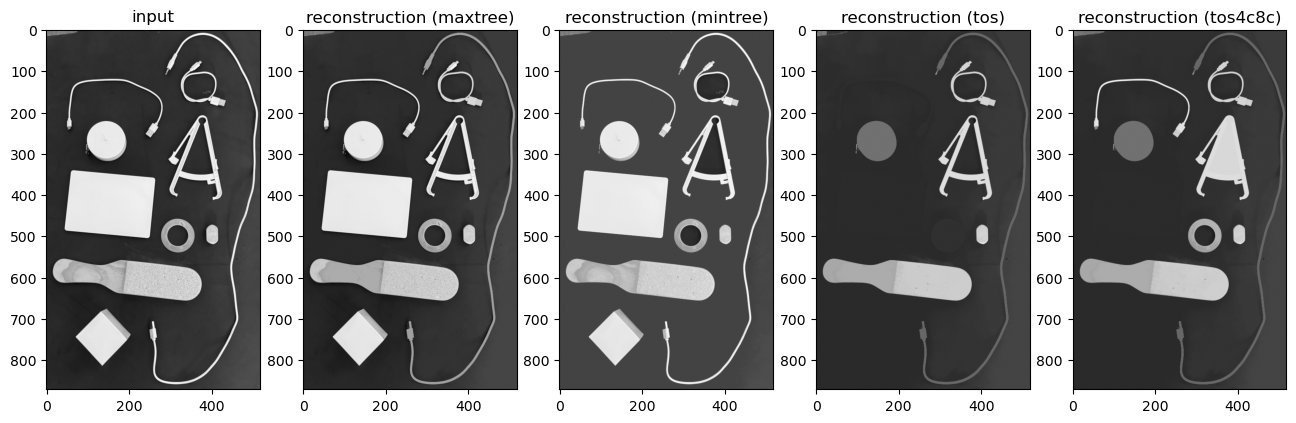

In [5]:
num_leafs = 20
attribute = Type.GRAY_HEIGHT

attr_maxtree = mmcfilters.Attribute.computeSingleAttribute(maxtree, attribute)
attr_mintree = mmcfilters.Attribute.computeSingleAttribute(mintree, attribute)
attr_tos = mmcfilters.Attribute.computeSingleAttribute(tos, attribute)
attr_tos4c8c = mmcfilters.Attribute.computeSingleAttribute(tos4c8c, attribute)



plt.subplot(1,5, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,5, 2)
plt.imshow(filterMaxtree.filteringByExtinction(attr_maxtree, num_leafs), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (maxtree)')

plt.subplot(1,5, 3)
plt.imshow(filterMintree.filteringByExtinction(attr_mintree, num_leafs), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (mintree)')

plt.subplot(1,5, 4)
plt.imshow(filterToS.filteringByExtinction(attr_tos, num_leafs), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (tos)')

plt.subplot(1,5, 5)
plt.imshow(filterToS4c8c.filteringByExtinction(attr_tos4c8c, num_leafs), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (tos4c8c)')

Text(0.5, 1.0, 'reconstruction (tos4c8c)')

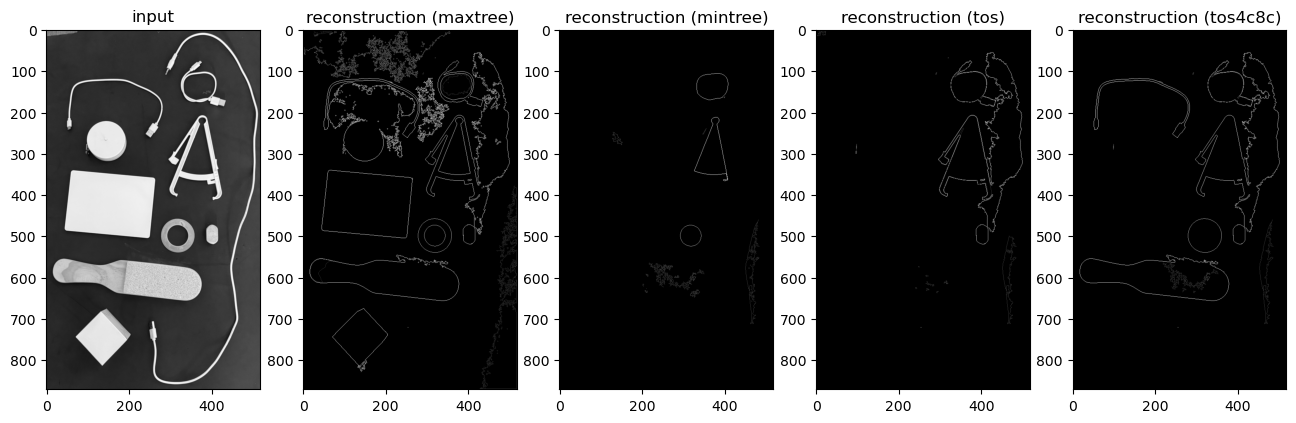

In [7]:

plt.subplot(1,5, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,5, 2)
plt.imshow(filterMaxtree.saliencyMapByExtinction(attr_maxtree, num_leafs).reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (maxtree)')

plt.subplot(1,5, 3)
plt.imshow(filterMintree.saliencyMapByExtinction(attr_mintree, num_leafs).reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (mintree)')

plt.subplot(1,5, 4)
plt.imshow(filterToS.saliencyMapByExtinction(attr_tos, num_leafs).reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (tos)')

plt.subplot(1,5, 5)
plt.imshow(filterToS4c8c.saliencyMapByExtinction(attr_tos4c8c, num_leafs).reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('reconstruction (tos4c8c)')

Text(0.5, 1.0, 'attribute filter (tos4c8c)')

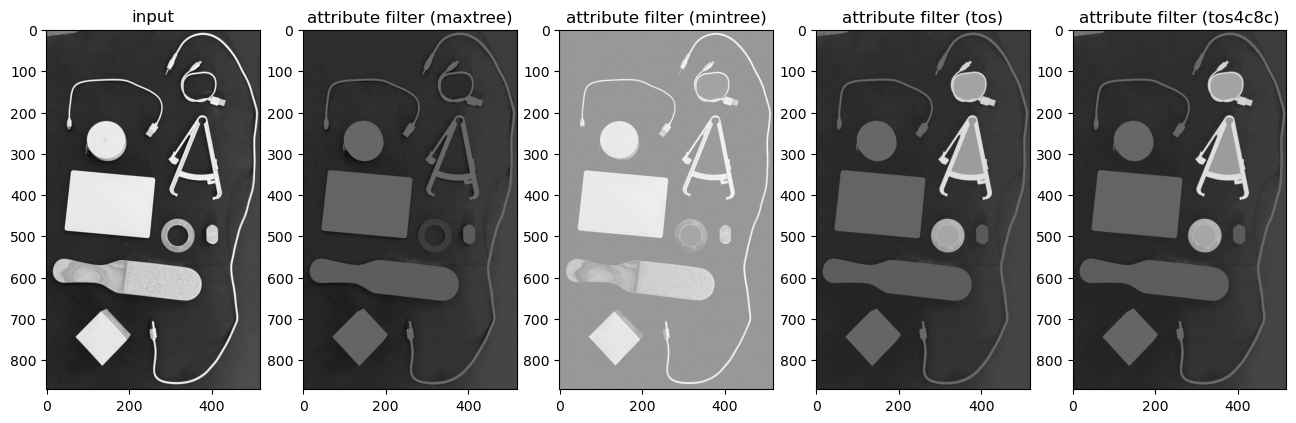

In [10]:
threshold = 150

imgFilteredMaxtree = filterMaxtree.filteringMax(attr_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringMax(attr_mintree > threshold)
imgFilteredToS = filterToS.filteringMax(attr_tos > threshold)
imgFilteredToS4c8c = filterToS4c8c.filteringMax(attr_tos4c8c > threshold)

plt.subplot(1,5, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,5, 2)
plt.imshow(imgFilteredMaxtree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,5, 3)
plt.imshow(imgFilteredMintree, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,5, 4)
plt.imshow(imgFilteredToS, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

plt.subplot(1,5, 5)
plt.imshow(imgFilteredToS4c8c, cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos4c8c)')